# 06 — Survival Analysis

**Scope:** Kaplan-Meier-Kurven (gesamt, nach Segmenten), Cox Proportional Hazards Model, Median Survival Times.

Diese Analyse ergaenzt die Klassifikationsmodelle (RF, XGBoost, LR) um eine **zeitliche Perspektive**:
- Klassifikation fragt: *Kuendigt dieser Kunde?*
- Survival Analysis fragt: *Wie lange dauert es, bis er kuendigt?*

Unsere Daten liefern die zwei Zutaten:
- `tenure` = Beobachtungsdauer in Monaten
- `Churn` = 1 (Ereignis eingetreten) oder 0 (zensiert = Kunde noch aktiv)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

from src.data_prep import load_raw_data, clean_data, add_features

sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["figure.figsize"] = (10, 6)

PLOT_DIR = "plots"
CONTRACT_COLORS = {"Month-to-month": "#e74c3c", "One year": "#f39c12", "Two year": "#27ae60"}
INTERNET_COLORS = {"Fiber optic": "#e74c3c", "DSL": "#3498db", "No": "#95a5a6"}
BINARY_COLORS = {0: "#3498db", 1: "#e74c3c"}

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
df_raw = load_raw_data()
df = clean_data(df_raw)
df = add_features(df)

T = df["tenure"].values
E = df["Churn"].values

print(f"Kunden: {len(df)}")
print(f"Davon gekuendigt (Event=1): {E.sum()} ({E.mean():.1%})")
print(f"Davon zensiert (Event=0): {(1-E).sum()} ({(1-E).mean():.1%})")
print(f"Tenure-Bereich: {T.min()} – {T.max()} Monate")

Kunden: 7043
Davon gekuendigt (Event=1): 1869 (26.5%)
Davon zensiert (Event=0): 5174 (73.5%)
Tenure-Bereich: 0 – 72 Monate


---
## 1. Kaplan-Meier-Kurve: Gesamte Population

> **So liest man eine Kaplan-Meier-Kurve:** Die Kurve zeigt die geschaetzte Wahrscheinlichkeit, dass ein Kunde zu einem bestimmten Zeitpunkt noch aktiv ist. Die x-Achse zeigt die Zeit (in Monaten), die y-Achse die Ueberlebenswahrscheinlichkeit (1.0 = 100% noch da, 0.0 = alle weg). Die Kurve faellt bei jedem beobachteten Kuendigungsereignis eine Stufe herunter. Das schattierte Band zeigt das 95%-Konfidenzintervall. Die **Median Survival Time** ist der Punkt, an dem die Kurve 0.5 (50%) kreuzt — ab diesem Zeitpunkt hat die Haelfte der Kunden gekuendigt.

Median Survival Time: Nicht erreicht (>50% der Kunden sind noch da)


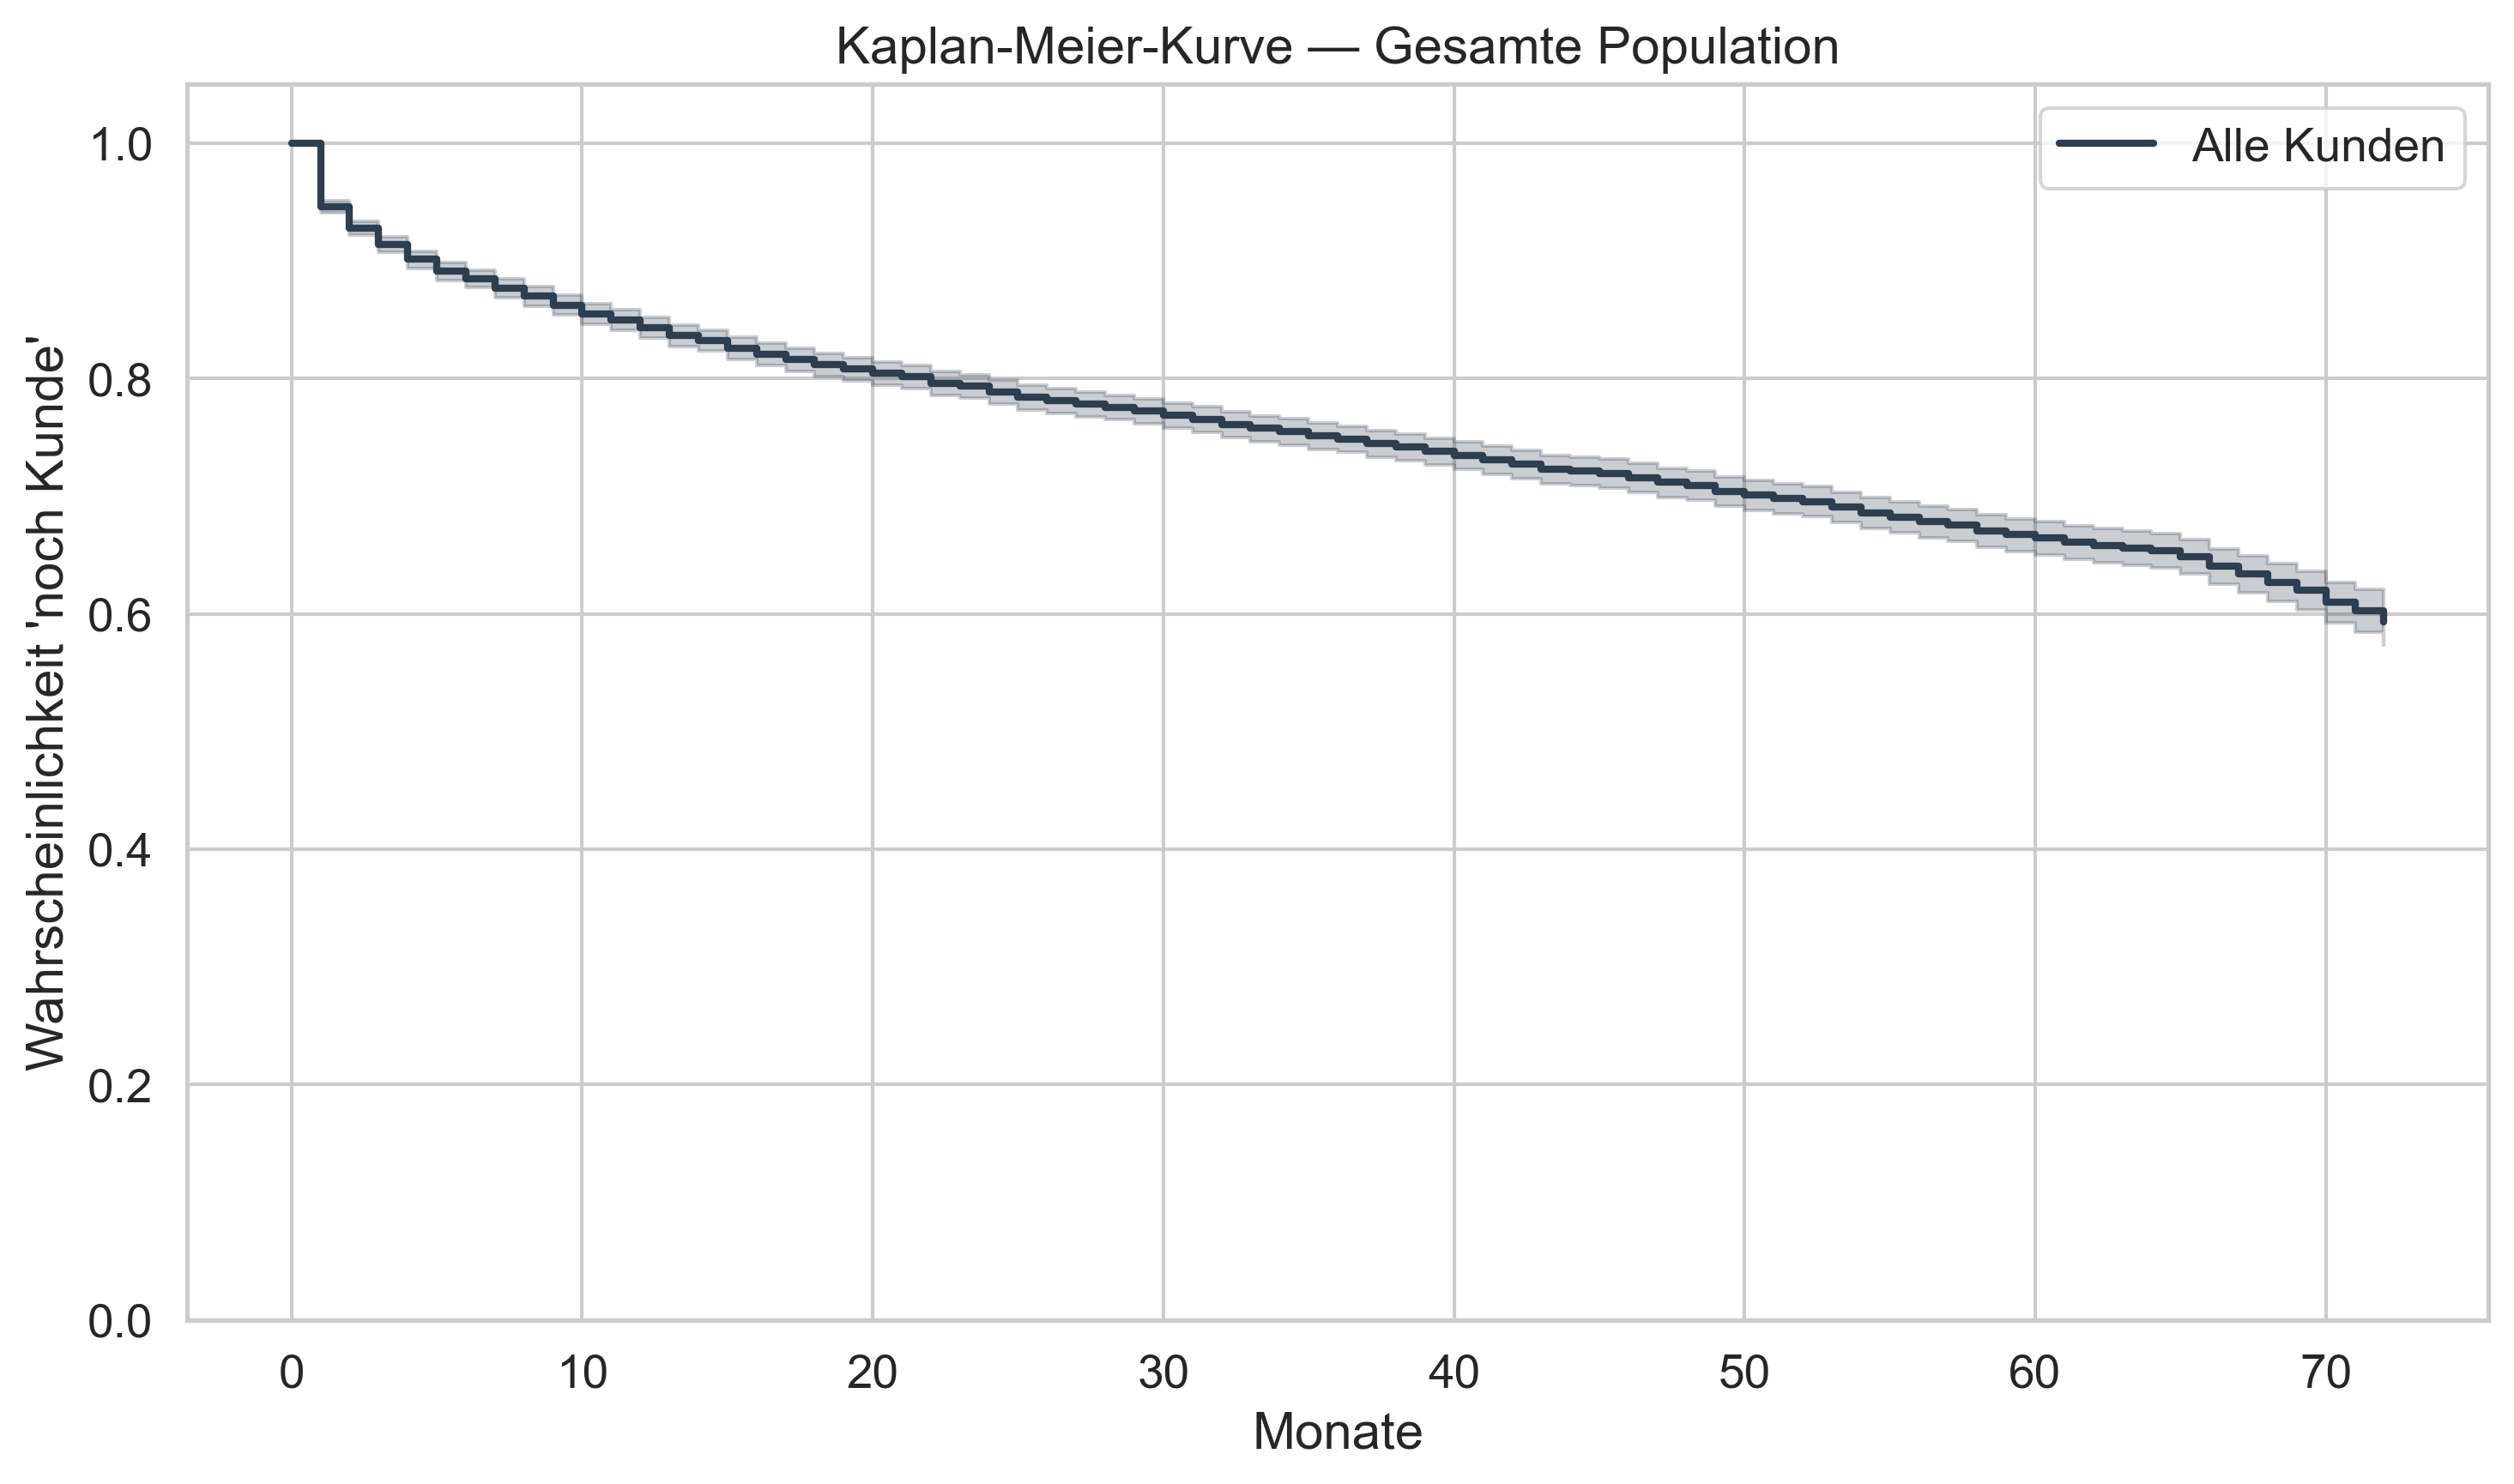

In [ ]:
kmf = KaplanMeierFitter()
kmf.fit(T, event_observed=E, label="Alle Kunden")

fig, ax = plt.subplots(figsize=(10, 6))
kmf.plot_survival_function(ax=ax, color="#2c3e50", linewidth=2)

median_st = kmf.median_survival_time_
if np.isfinite(median_st):
    ax.axhline(0.5, color="grey", linestyle="--", alpha=0.5)
    ax.axvline(median_st, color="grey", linestyle="--", alpha=0.5)
    ax.annotate(f"Median: {median_st:.0f} Monate", xy=(median_st, 0.5),
                xytext=(median_st + 5, 0.55), fontsize=12,
                arrowprops=dict(arrowstyle="->"))
    print(f"Median Survival Time (gesamt): {median_st:.0f} Monate")
else:
    print("Median Survival Time: Nicht erreicht (>50% der Kunden sind noch da)")

ax.set_xlabel("Monate")
ax.set_ylabel("Wahrscheinlichkeit 'noch Kunde'")
ax.set_title("Kaplan-Meier-Kurve — Gesamte Population")
ax.set_ylim(0, 1.05)
plt.tight_layout()
fig.savefig(f"{PLOT_DIR}/33_kaplan_meier_gesamt.png")
plt.show()

---
## 2. Kaplan-Meier nach Vertragstyp

Der Vertragstyp ist der staerkste Churn-Treiber. Wie unterscheiden sich die Ueberlebenskurven?

Month-to-month: Median Survival = 35 Monate
One year: Median Survival = >72 Monate (nicht erreicht)
Two year: Median Survival = >72 Monate (nicht erreicht)


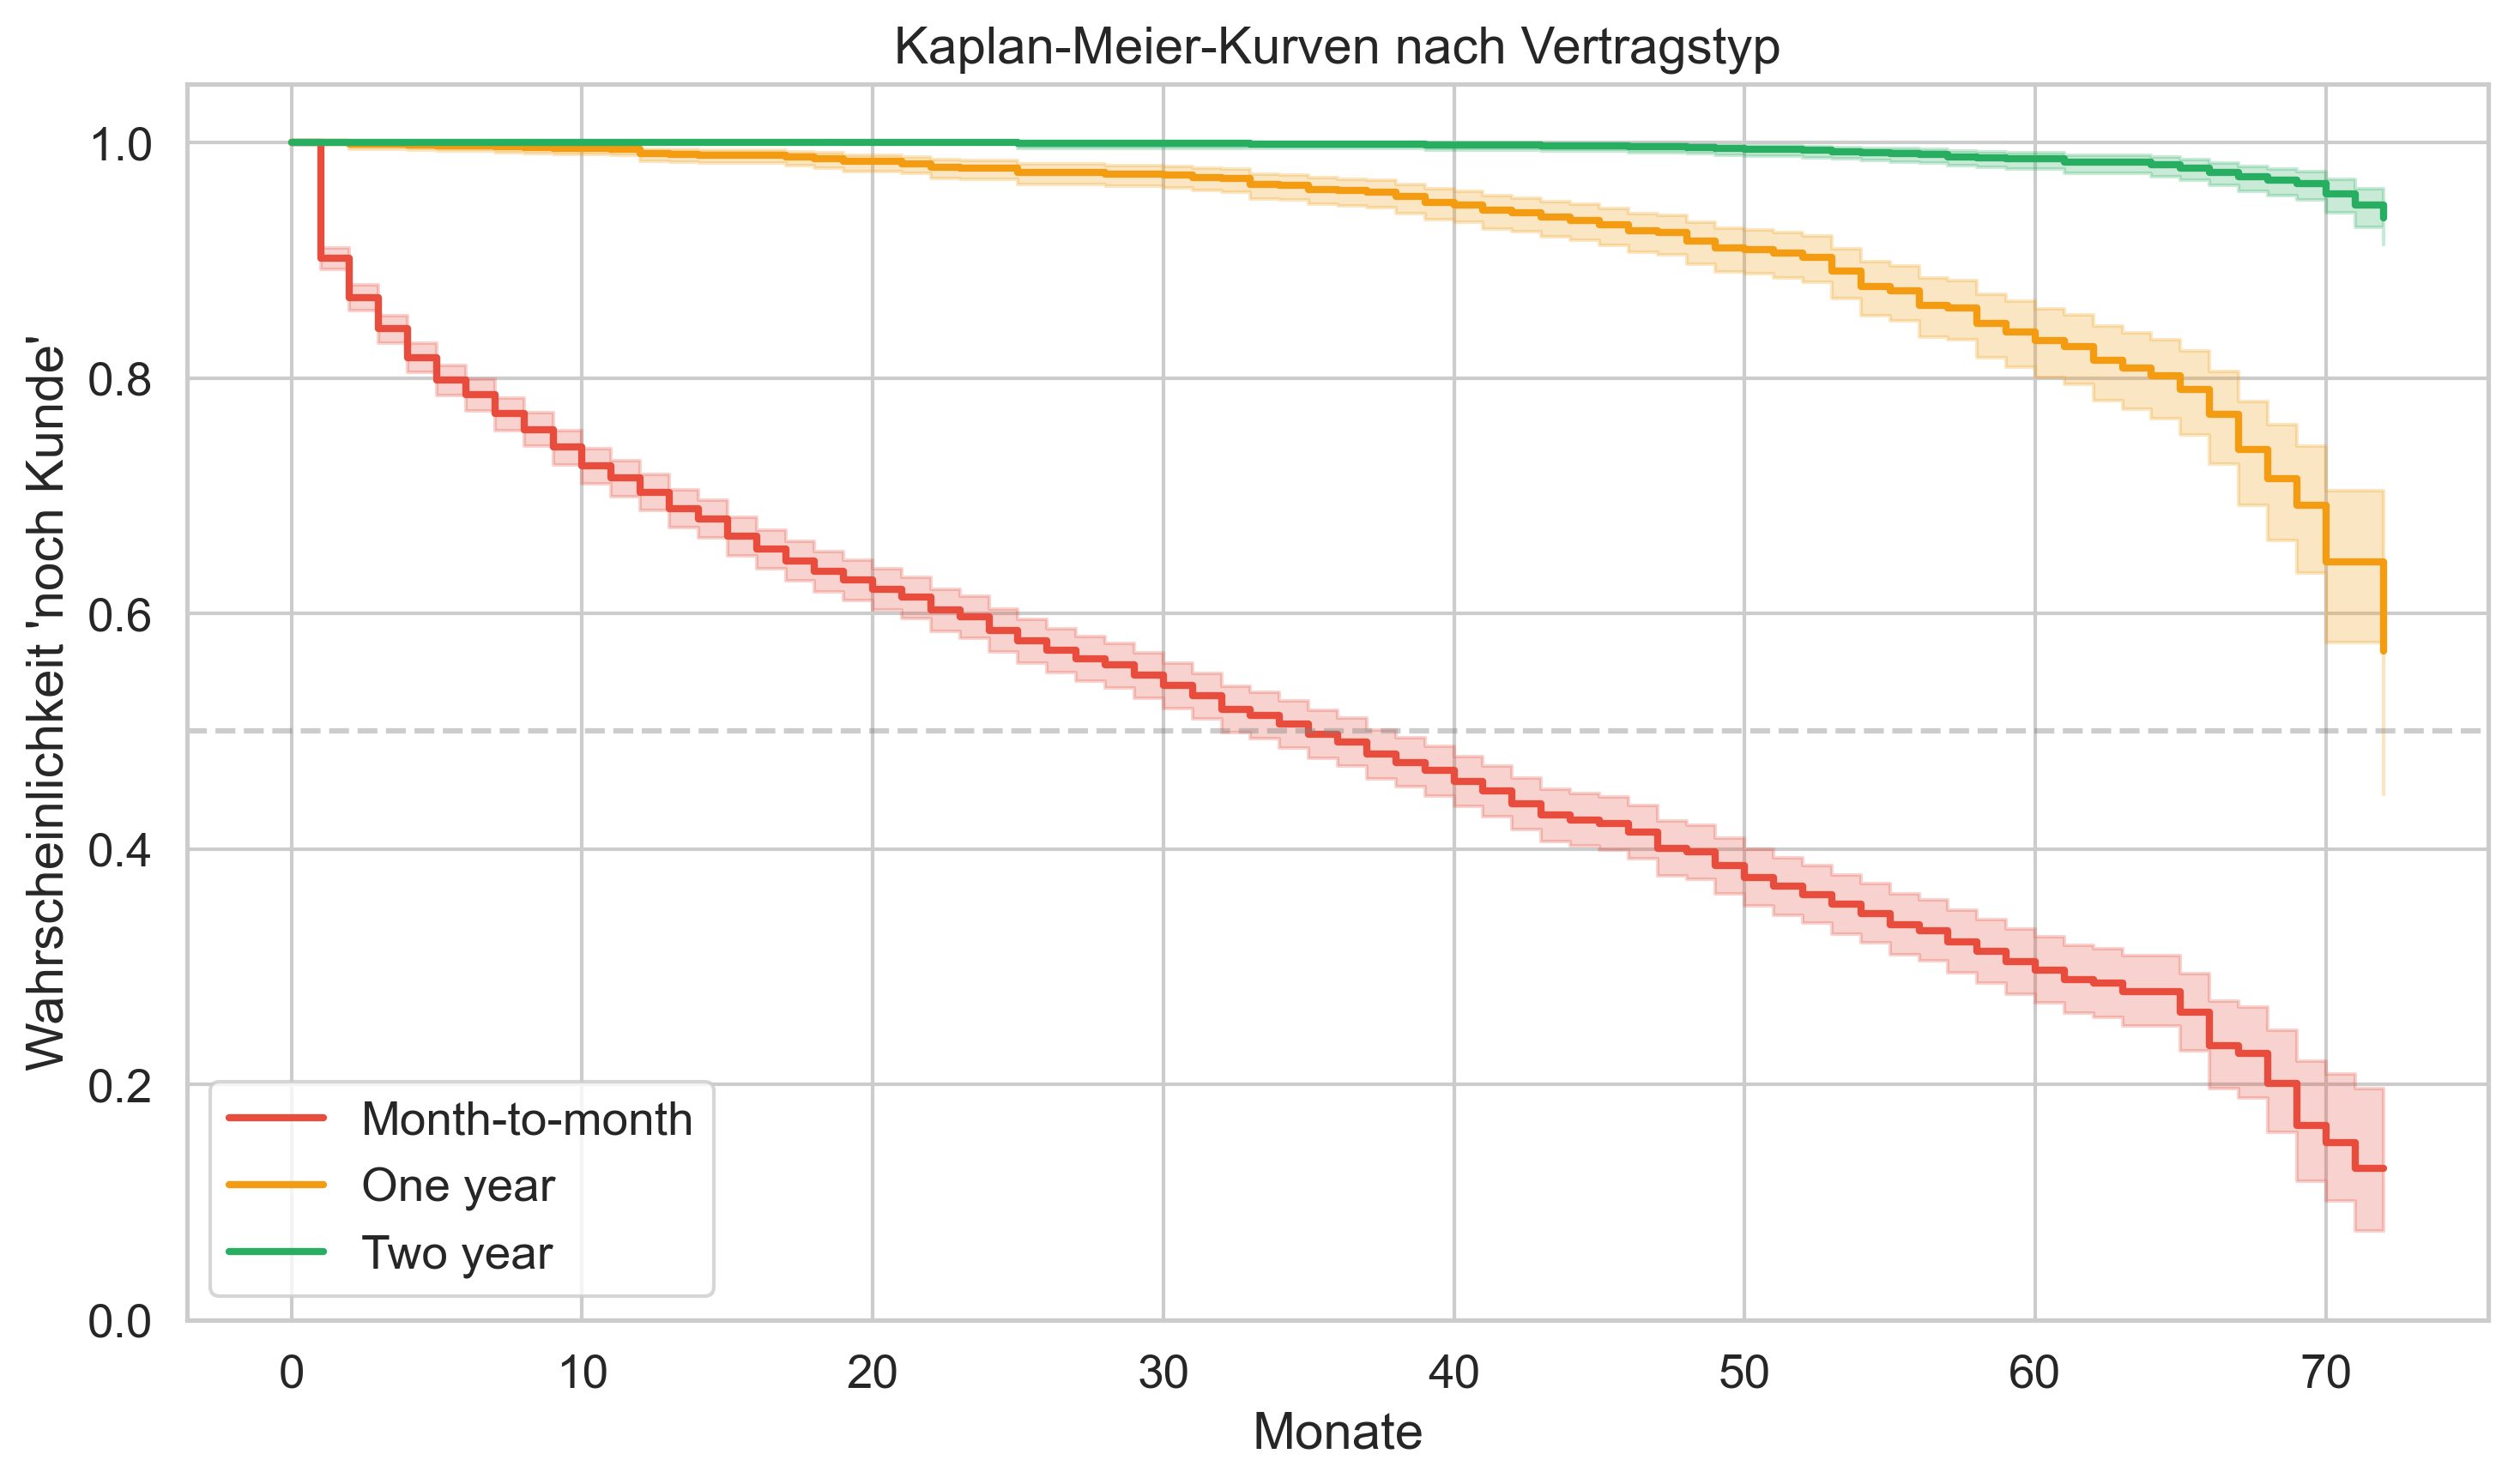


Log-rank Test (Month-to-month vs. Two year): p = 0.00e+00
Statistisch signifikant: Ja


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

groups = {}
for contract_type, color in CONTRACT_COLORS.items():
    mask = df["Contract"] == contract_type
    kmf_c = KaplanMeierFitter()
    kmf_c.fit(T[mask], event_observed=E[mask], label=contract_type)
    kmf_c.plot_survival_function(ax=ax, color=color, linewidth=2)
    groups[contract_type] = (T[mask], E[mask])
    median_t = kmf_c.median_survival_time_
    if np.isfinite(median_t):
        print(f"{contract_type}: Median Survival = {median_t:.0f} Monate")
    else:
        print(f"{contract_type}: Median Survival = >72 Monate (nicht erreicht)")

ax.axhline(0.5, color="grey", linestyle="--", alpha=0.4)
ax.set_xlabel("Monate")
ax.set_ylabel("Wahrscheinlichkeit 'noch Kunde'")
ax.set_title("Kaplan-Meier-Kurven nach Vertragstyp")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower left")
plt.tight_layout()
fig.savefig(f"{PLOT_DIR}/34_kaplan_meier_nach_contract.png")
plt.show()

# Log-rank Test: Month-to-month vs. Two year
lr = logrank_test(groups["Month-to-month"][0], groups["Two year"][0],
                  event_observed_A=groups["Month-to-month"][1],
                  event_observed_B=groups["Two year"][1])
print(f"\nLog-rank Test (Month-to-month vs. Two year): p = {lr.p_value:.2e}")
print(f"Statistisch signifikant: {'Ja' if lr.p_value < 0.001 else 'Nein'}")

---
## 3. Kaplan-Meier nach Internet-Service

Fiber optic: Median Survival = 65 Monate
DSL: Median Survival = >72 Monate (nicht erreicht)
No: Median Survival = >72 Monate (nicht erreicht)


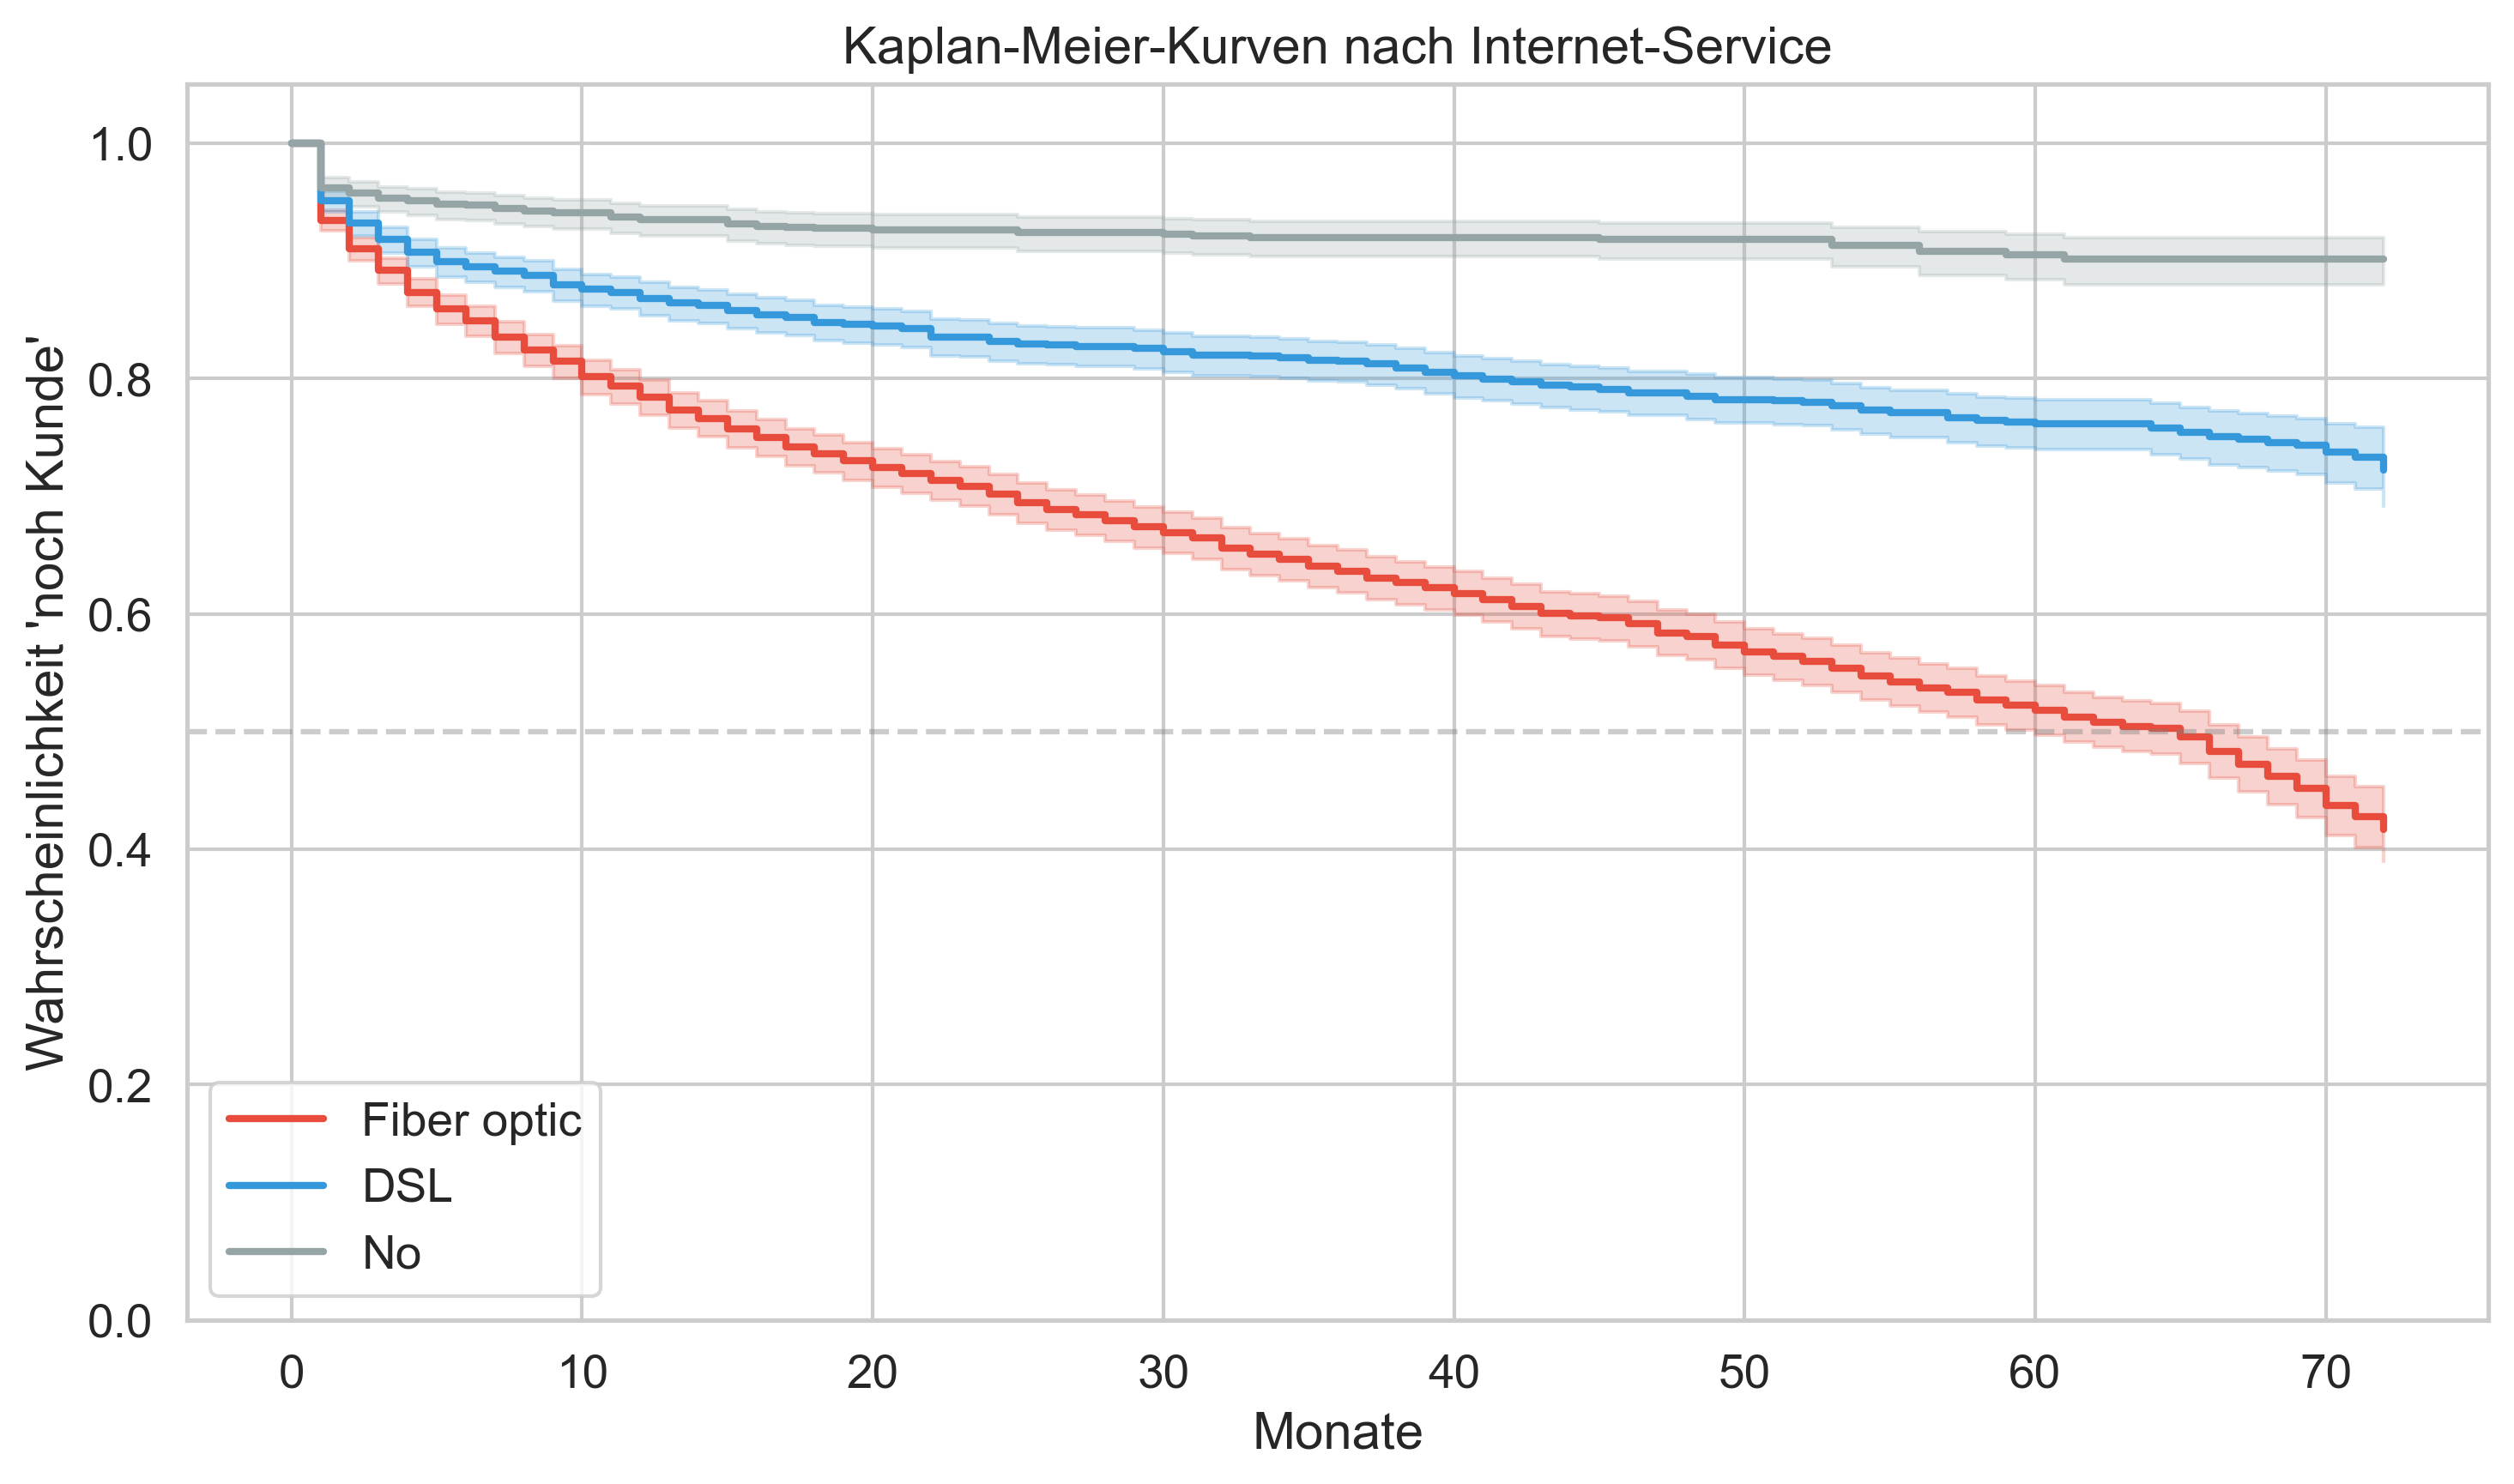

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

for service, color in INTERNET_COLORS.items():
    mask = df["InternetService"] == service
    kmf_i = KaplanMeierFitter()
    kmf_i.fit(T[mask], event_observed=E[mask], label=service)
    kmf_i.plot_survival_function(ax=ax, color=color, linewidth=2)
    median_t = kmf_i.median_survival_time_
    if np.isfinite(median_t):
        print(f"{service}: Median Survival = {median_t:.0f} Monate")
    else:
        print(f"{service}: Median Survival = >72 Monate (nicht erreicht)")

ax.axhline(0.5, color="grey", linestyle="--", alpha=0.4)
ax.set_xlabel("Monate")
ax.set_ylabel("Wahrscheinlichkeit 'noch Kunde'")
ax.set_title("Kaplan-Meier-Kurven nach Internet-Service")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower left")
plt.tight_layout()
fig.savefig(f"{PLOT_DIR}/35_kaplan_meier_nach_internet.png")
plt.show()

---
## 4. Kaplan-Meier nach SeniorCitizen

Nicht-Senior: Median Survival = >72 Monate (nicht erreicht)
Senior (65+): Median Survival = 65 Monate


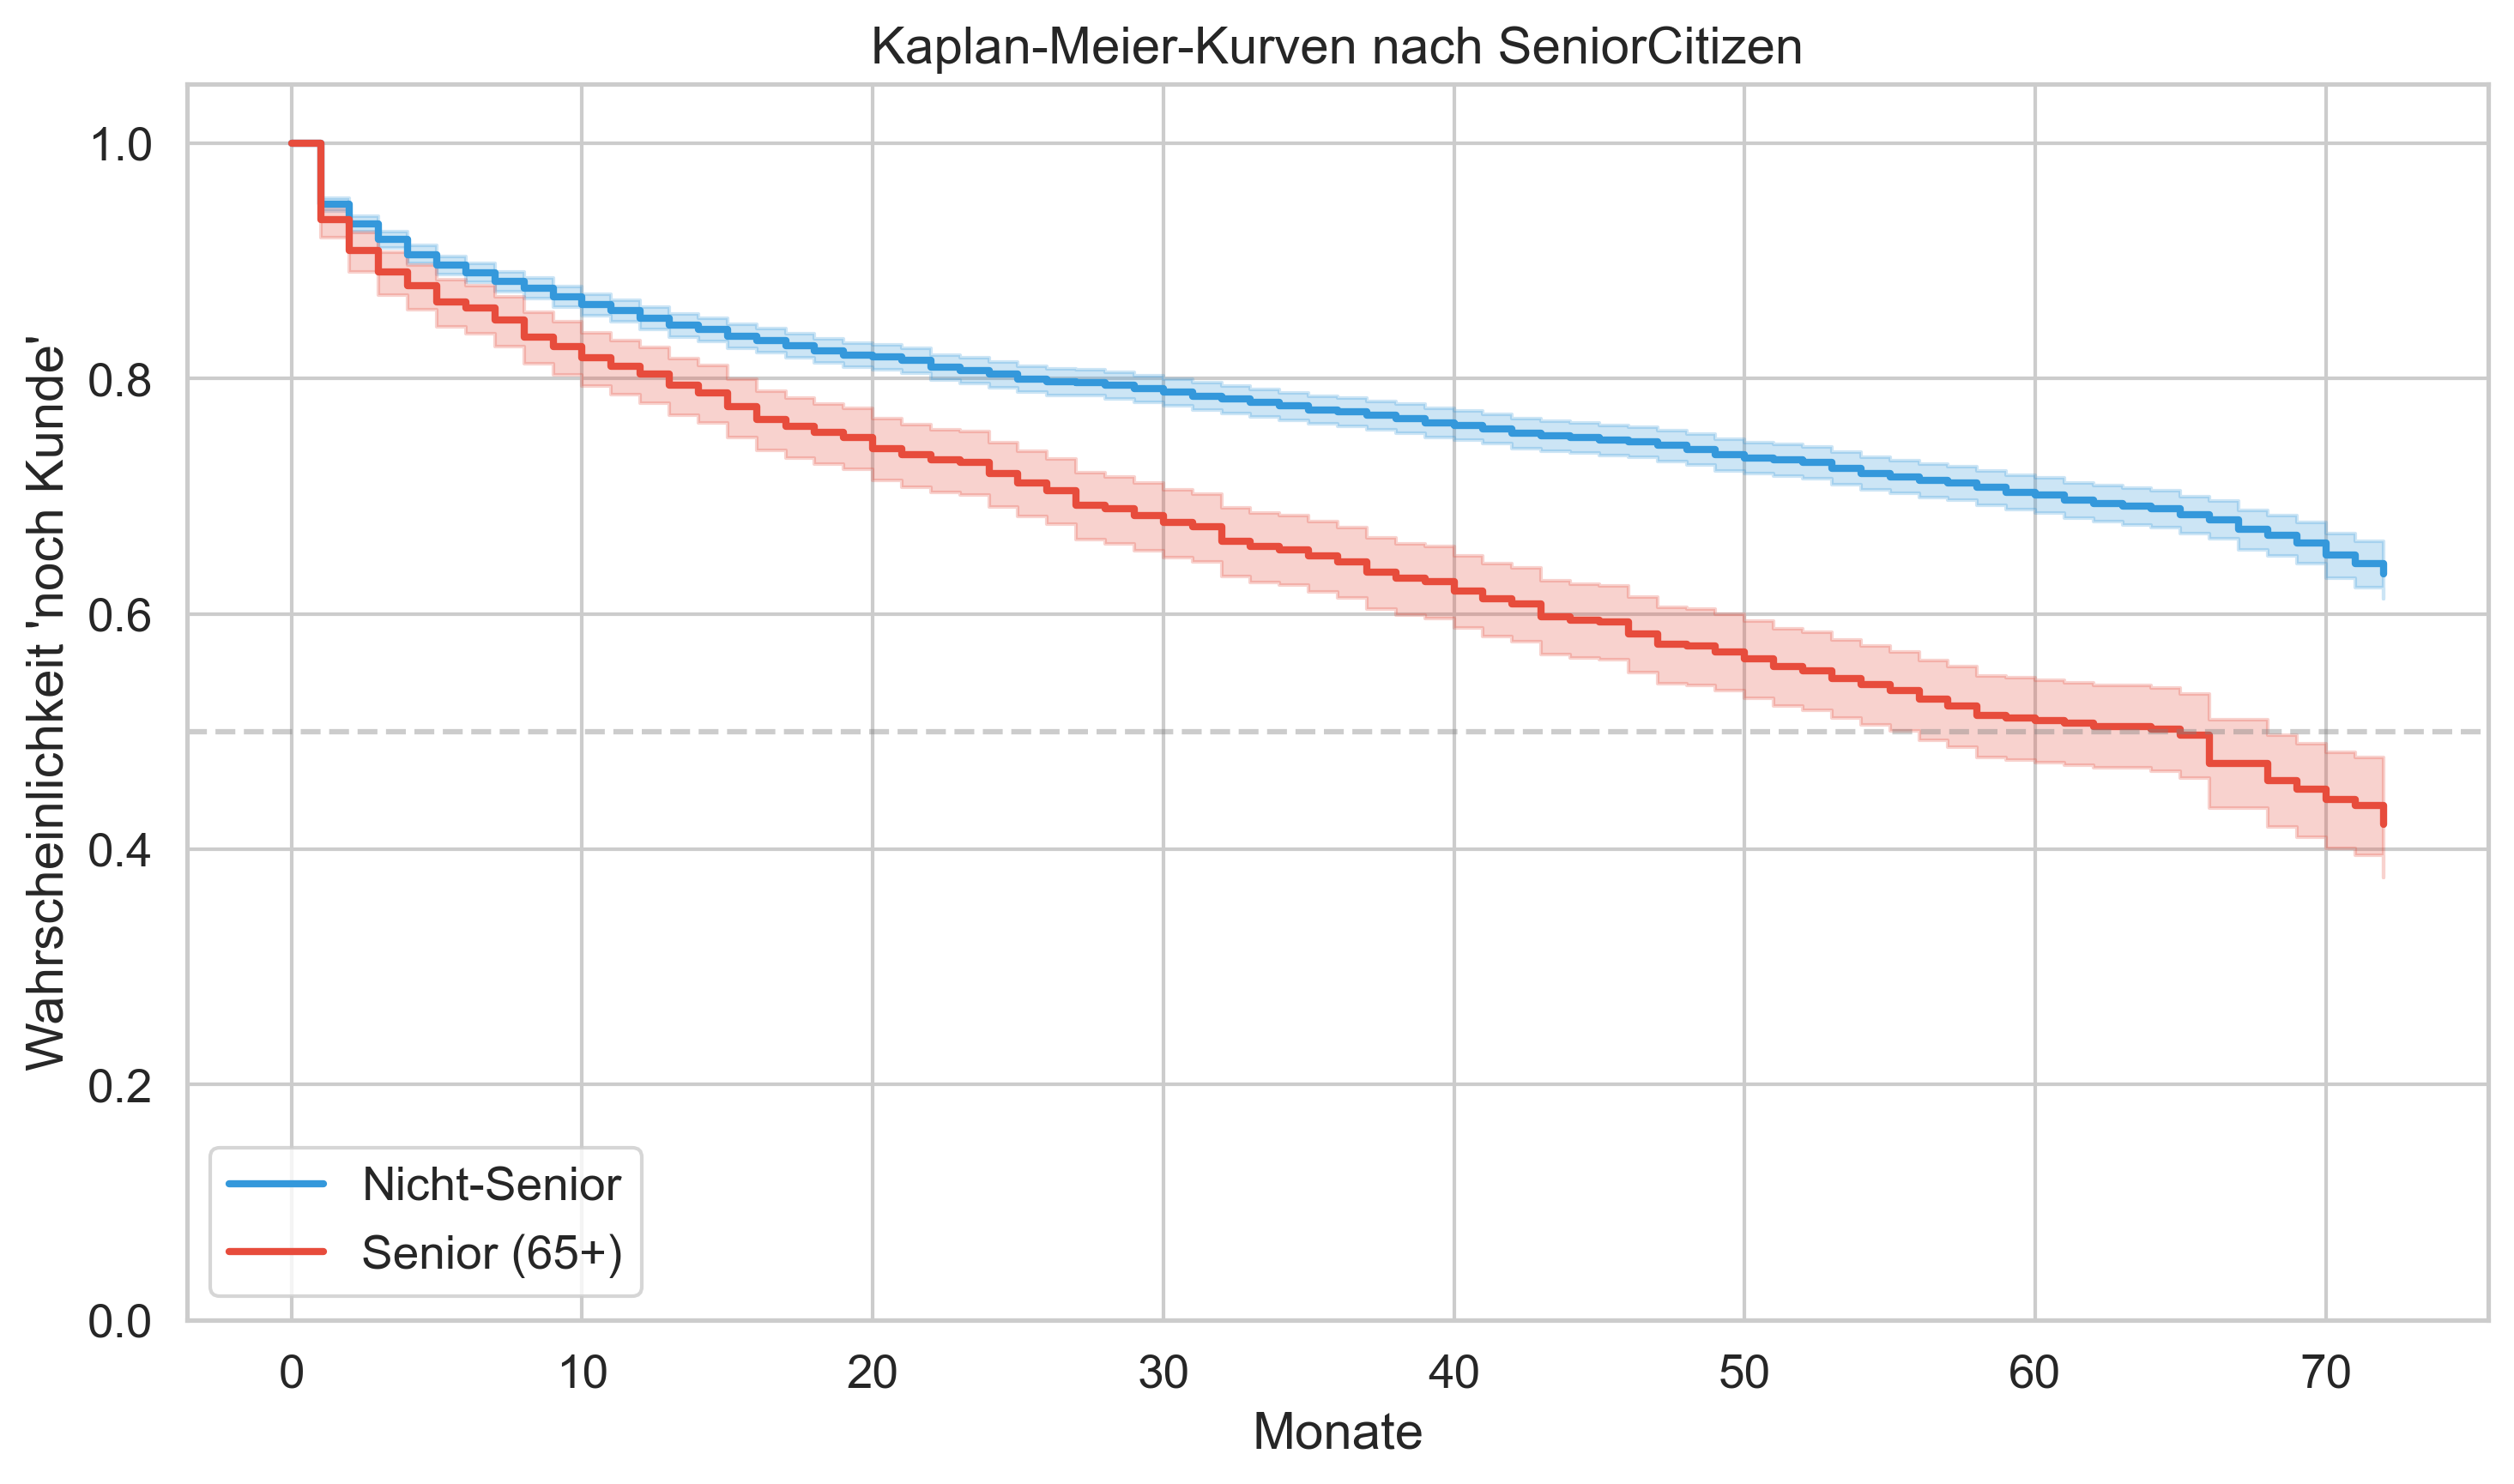

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

for val, label in [(0, "Nicht-Senior"), (1, "Senior (65+)")]:
    mask = df["SeniorCitizen"] == val
    kmf_s = KaplanMeierFitter()
    kmf_s.fit(T[mask], event_observed=E[mask], label=label)
    kmf_s.plot_survival_function(ax=ax, color=BINARY_COLORS[val], linewidth=2)
    median_t = kmf_s.median_survival_time_
    if np.isfinite(median_t):
        print(f"{label}: Median Survival = {median_t:.0f} Monate")
    else:
        print(f"{label}: Median Survival = >72 Monate (nicht erreicht)")

ax.axhline(0.5, color="grey", linestyle="--", alpha=0.4)
ax.set_xlabel("Monate")
ax.set_ylabel("Wahrscheinlichkeit 'noch Kunde'")
ax.set_title("Kaplan-Meier-Kurven nach SeniorCitizen")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower left")
plt.tight_layout()
fig.savefig(f"{PLOT_DIR}/36_kaplan_meier_nach_senior.png")
plt.show()

---
## 5. Kaplan-Meier nach HasSupport (TechSupport/OnlineSecurity)

Kein Support: Median Survival = 68 Monate
Hat Support: Median Survival = >72 Monate (nicht erreicht)


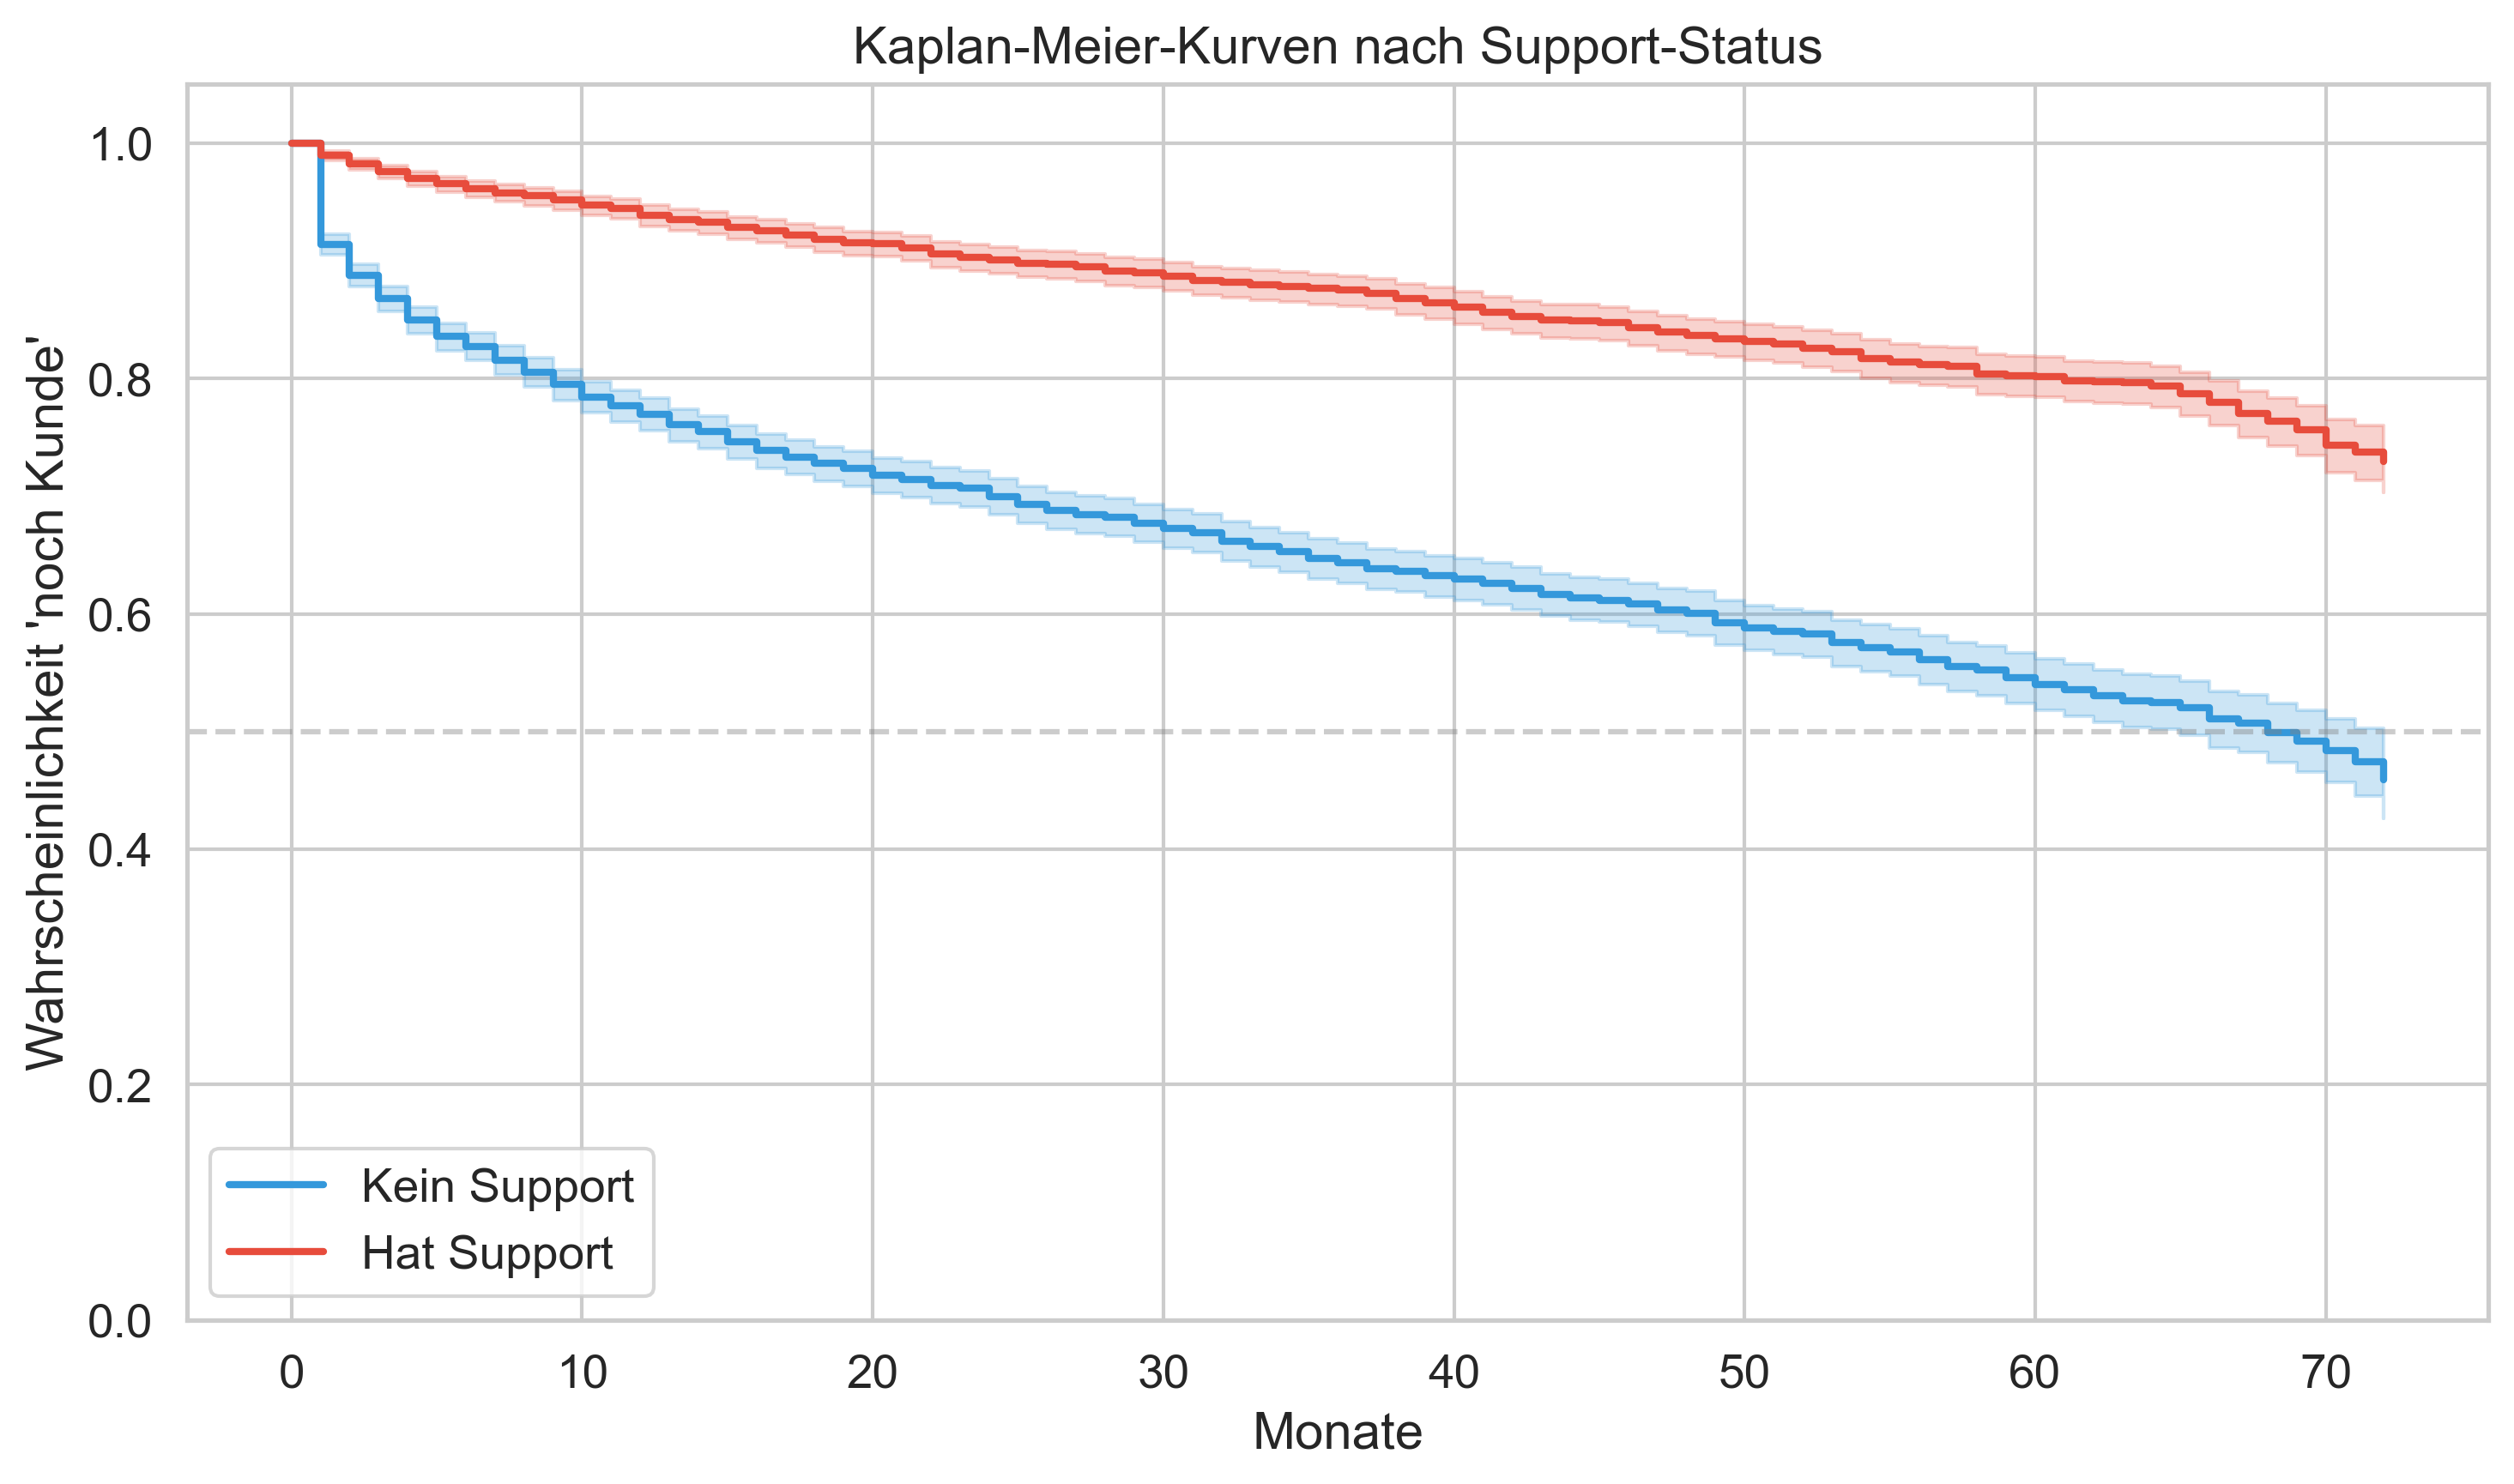

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

for val, label in [(0, "Kein Support"), (1, "Hat Support")]:
    mask = df["HasSupport"] == val
    kmf_h = KaplanMeierFitter()
    kmf_h.fit(T[mask], event_observed=E[mask], label=label)
    kmf_h.plot_survival_function(ax=ax, color=BINARY_COLORS[val], linewidth=2)
    median_t = kmf_h.median_survival_time_
    if np.isfinite(median_t):
        print(f"{label}: Median Survival = {median_t:.0f} Monate")
    else:
        print(f"{label}: Median Survival = >72 Monate (nicht erreicht)")

ax.axhline(0.5, color="grey", linestyle="--", alpha=0.4)
ax.set_xlabel("Monate")
ax.set_ylabel("Wahrscheinlichkeit 'noch Kunde'")
ax.set_title("Kaplan-Meier-Kurven nach Support-Status")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower left")
plt.tight_layout()
fig.savefig(f"{PLOT_DIR}/37_kaplan_meier_nach_support.png")
plt.show()

---
## 6. Cox Proportional Hazards Model

> **So liest man Hazard Ratios:** Das Cox-Modell schaetzt fuer jedes Feature eine **Hazard Ratio (HR)**:
> - **HR = 1.0**: Kein Effekt
> - **HR > 1.0**: Erhoehtes Kuendigungsrisiko (z.B. HR=2.0 → doppeltes Risiko pro Zeiteinheit)
> - **HR < 1.0**: Verringertes Kuendigungsrisiko (z.B. HR=0.5 → halbes Risiko)
>
> Der Forest-Plot zeigt die HR mit Konfidenzintervall. Wenn das Intervall die 1.0-Linie nicht kreuzt, ist der Effekt statistisch signifikant.

In [ ]:
cox_df = df[["tenure", "Churn", "SeniorCitizen", "Partner",
             "HasSupport", "MonthlyCharges", "Contract",
             "InternetService", "PaymentMethod"]].copy()

cox_df["Partner"] = (cox_df["Partner"] == "Yes").astype(int)
cox_df["Contract_Monthly"] = (cox_df["Contract"] == "Month-to-month").astype(int)
cox_df["Contract_OneYear"] = (cox_df["Contract"] == "One year").astype(int)
cox_df["Internet_Fiber"] = (cox_df["InternetService"] == "Fiber optic").astype(int)
cox_df["Internet_No"] = (cox_df["InternetService"] == "No").astype(int)
cox_df["Payment_ECheck"] = (cox_df["PaymentMethod"] == "Electronic check").astype(int)

cox_df.drop(columns=["Contract", "InternetService", "PaymentMethod"], inplace=True)

cph = CoxPHFitter()
cph.fit(cox_df, duration_col="tenure", event_col="Churn")
cph.print_summary(columns=["coef", "exp(coef)", "p", "exp(coef) lower 95%", "exp(coef) upper 95%"])

<lifelines.CoxPHFitter: fitted with 7043 total observations, 5174 right-censored observations>
             duration col = 'tenure'
                event col = 'Churn'
      baseline estimation = breslow
   number of observations = 7043
number of events observed = 1869
   partial log-likelihood = -14022.24
         time fit was run = 2026-04-16 07:41:21 UTC

---
                  coef exp(coef) exp(coef) lower 95% exp(coef) upper 95%      p
covariate                                                                      
SeniorCitizen    -0.12      0.88                0.79                0.98   0.02
Partner          -0.59      0.56                0.50                0.61 <0.005
HasSupport       -0.56      0.57                0.51                0.64 <0.005
MonthlyCharges   -0.02      0.98                0.97                0.98 <0.005
Contract_Monthly  3.41     30.12               21.86               41.52 <0.005
Contract_OneYear  1.70      5.49                3.93                7.66 <0.005
Internet_Fiber    1.09      2.97                2.41                3.66 <0.005
Internet_No      -1.26      0.28                0.22                0.36 <0.005
Payment_ECheck    0.48      1.61                1.46                1.78 <0.005
---
Concordance = 0.85
Partial AIC = 28062.49
log-likelihood ratio test = 3261.59 on 9 df
-log2(p) of ll-ratio test = inf

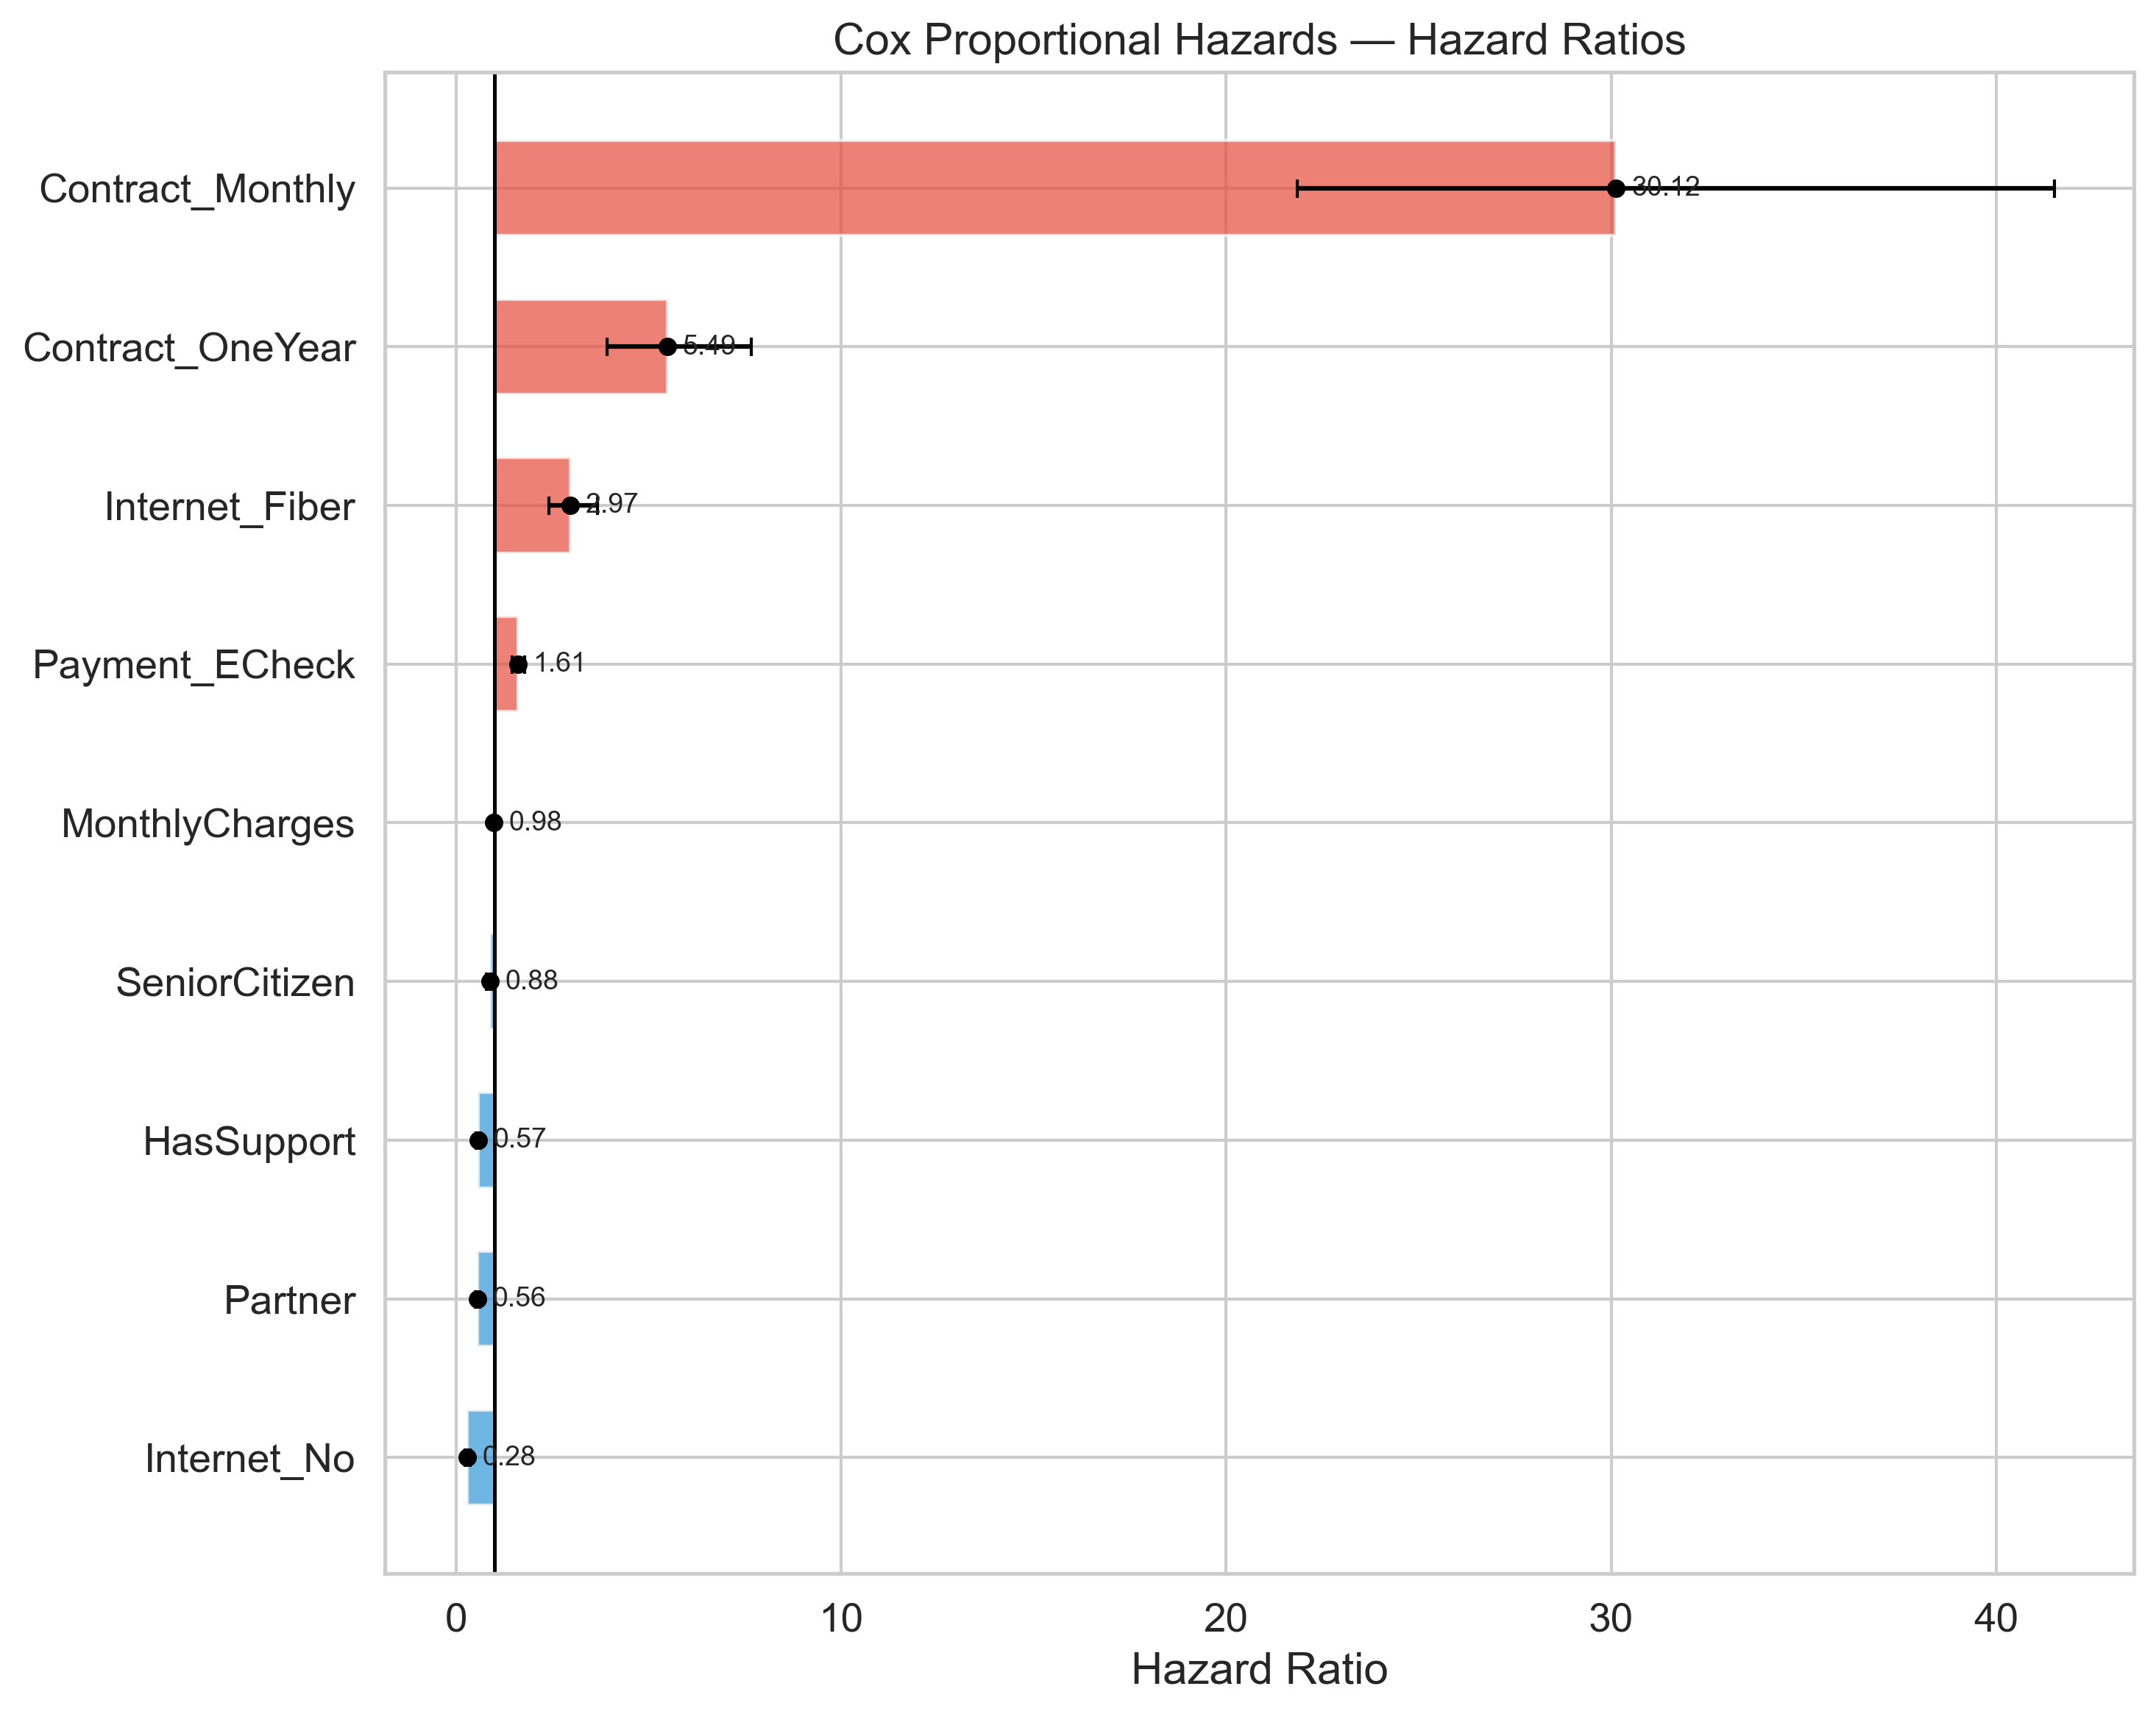

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

summary = cph.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%"]].copy()
summary.columns = ["HR", "Lower", "Upper"]
summary = summary.sort_values("HR")

colors = ["#e74c3c" if hr > 1 else "#3498db" for hr in summary["HR"]]
y_pos = range(len(summary))

ax.barh(y_pos, summary["HR"] - 1, left=1, color=colors, alpha=0.7, height=0.6)
ax.errorbar(summary["HR"], y_pos,
            xerr=[summary["HR"] - summary["Lower"], summary["Upper"] - summary["HR"]],
            fmt="o", color="black", markersize=5, capsize=3)

ax.axvline(1.0, color="black", linewidth=1.2, linestyle="-")
ax.set_yticks(list(y_pos))
ax.set_yticklabels(summary.index)
ax.set_xlabel("Hazard Ratio")
ax.set_title("Cox Proportional Hazards — Hazard Ratios")

for i, (idx, row) in enumerate(summary.iterrows()):
    ax.annotate(f"{row['HR']:.2f}", xy=(row['HR'], i),
                xytext=(5, 0), textcoords="offset points",
                fontsize=9, va="center")

plt.tight_layout()
fig.savefig(f"{PLOT_DIR}/38_cox_hazard_ratios.png")
plt.show()

---
## 7. Median Survival Time nach Segment

In [ ]:
segments = {
    "Vertragstyp": ("Contract", ["Month-to-month", "One year", "Two year"]),
    "Internet": ("InternetService", ["Fiber optic", "DSL", "No"]),
    "Senior": ("SeniorCitizen", [0, 1]),
    "Support": ("HasSupport", [0, 1]),
}

rows = []
for seg_name, (col, values) in segments.items():
    for val in values:
        mask = df[col] == val
        kmf_t = KaplanMeierFitter()
        kmf_t.fit(T[mask], event_observed=E[mask])
        med = kmf_t.median_survival_time_
        n = mask.sum()
        churn_rate = E[mask].mean()
        rows.append({
            "Segment": seg_name,
            "Wert": str(val),
            "Anzahl": n,
            "Churn-Rate": f"{churn_rate:.1%}",
            "Median Survival (Monate)": f"{med:.0f}" if np.isfinite(med) else ">72",
        })

median_df = pd.DataFrame(rows)
print(median_df.to_string(index=False))

    Segment           Wert  Anzahl Churn-Rate Median Survival (Monate)
Vertragstyp Month-to-month    3875      42.7%                       35
Vertragstyp       One year    1473      11.3%                      >72
Vertragstyp       Two year    1695       2.8%                      >72
   Internet    Fiber optic    3096      41.9%                       65
   Internet            DSL    2421      19.0%                      >72
   Internet             No    1526       7.4%                      >72
     Senior              0    5901      23.6%                      >72
     Senior              1    1142      41.7%                       65
    Support              0    4079      33.4%                       68
    Support              1    2964      17.1%                      >72


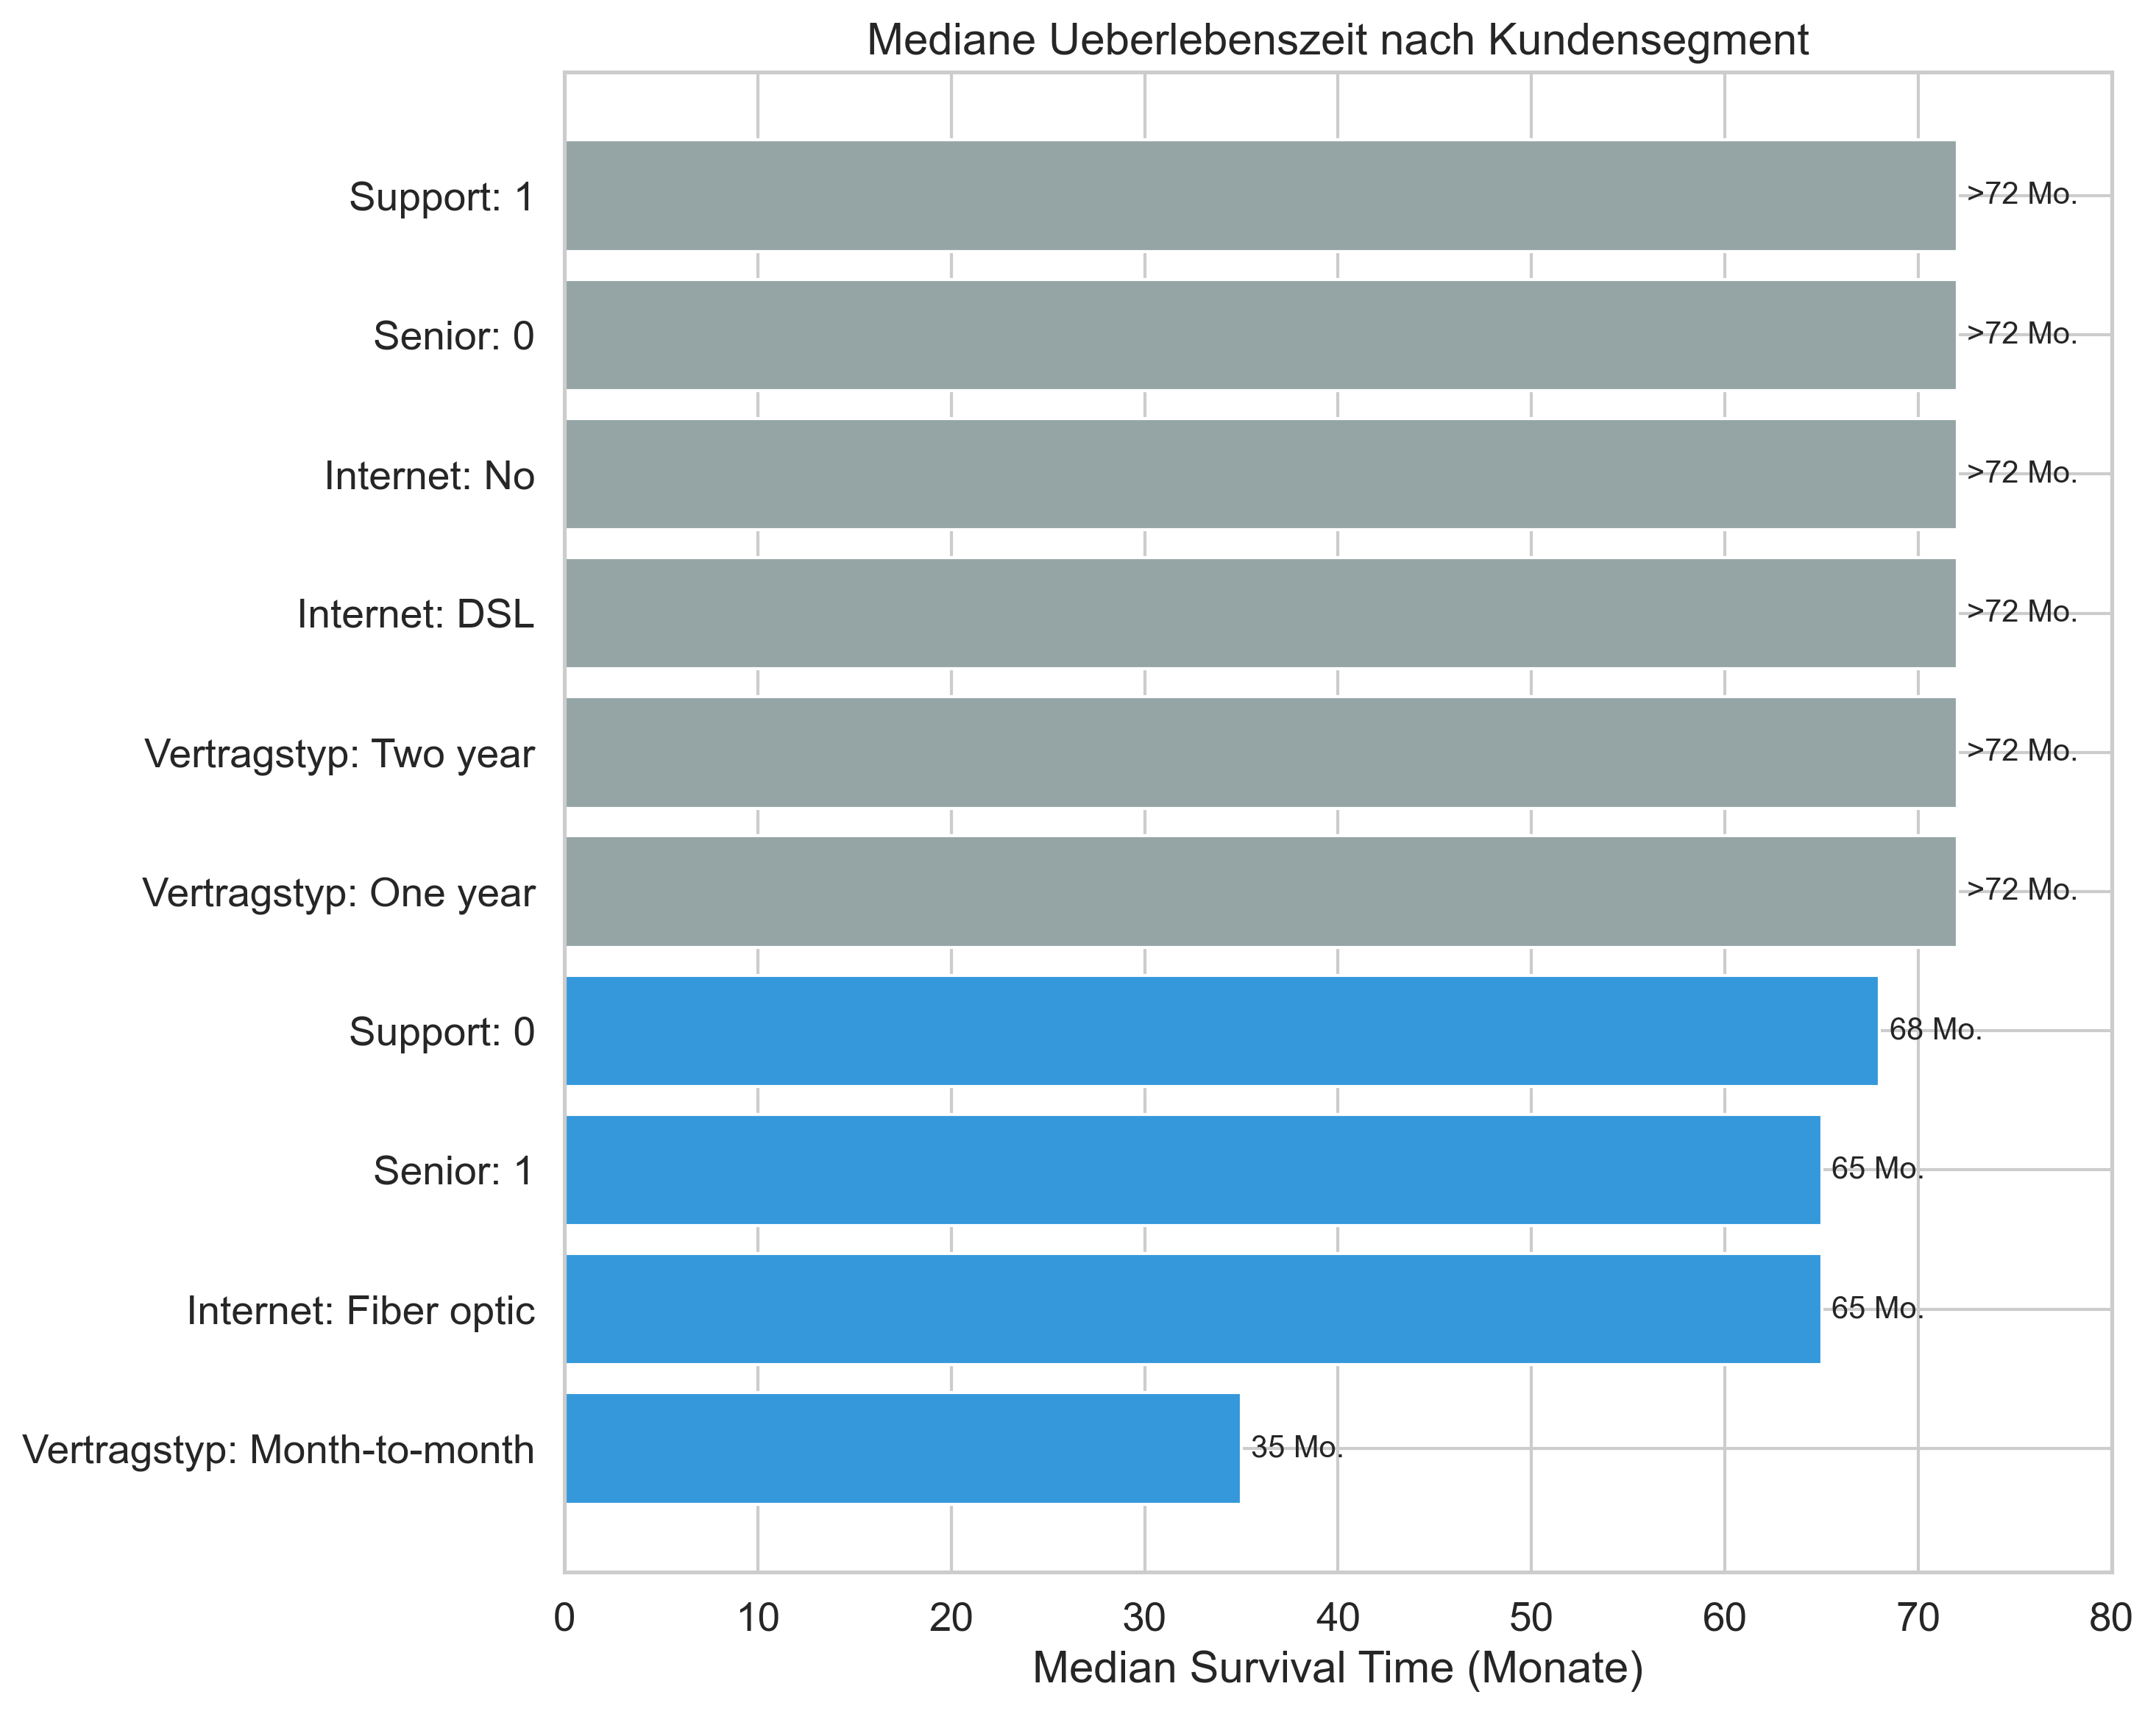

In [ ]:
plot_data = []
for _, row in median_df.iterrows():
    val = row["Median Survival (Monate)"]
    plot_data.append({
        "label": f"{row['Segment']}: {row['Wert']}",
        "median": float(val) if val != ">72" else 72,
        "capped": val == ">72",
    })

pdf = pd.DataFrame(plot_data).sort_values("median")

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#95a5a6" if c else "#3498db" for c in pdf["capped"]]
bars = ax.barh(range(len(pdf)), pdf["median"], color=colors, edgecolor="white")

for i, (_, r) in enumerate(pdf.iterrows()):
    txt = f"{r['median']:.0f}" if not r["capped"] else ">72"
    ax.text(r["median"] + 0.5, i, f"{txt} Mo.", va="center", fontsize=10)

ax.set_yticks(range(len(pdf)))
ax.set_yticklabels(pdf["label"])
ax.set_xlabel("Median Survival Time (Monate)")
ax.set_title("Mediane Ueberlebenszeit nach Kundensegment")
ax.set_xlim(0, 80)
plt.tight_layout()
fig.savefig(f"{PLOT_DIR}/39_median_survival_by_segment.png")
plt.show()

---
## Fazit

Die Survival Analysis ergaenzt unsere Klassifikationsmodelle:
- **XGBoost/RF** sagen **WEN** man anrufen soll (Churn-Wahrscheinlichkeit)
- **Survival Analysis** sagt **WANN** man handeln muss (wie viel Zeit bleibt)

Die Kombination ist maechtig: Kunden mit hohem Churn-Score UND niedriger Median Survival Time brauchen sofortige Aufmerksamkeit.